In [1]:
%load_ext autoreload
%autoreload 2
from src import datasets

data = datasets.LibrispeechDataset(part="dev-clean")

In [2]:
from src.text_encoder.ctc_text_encoder import CTCTextEncoder
from torchaudio.transforms import MelSpectrogram
instance_transforms = {
    "get_spectrogram": MelSpectrogram(
        sample_rate=16000,
        win_length=400
    )
}
data.instance_transforms = instance_transforms
data.text_encoder = CTCTextEncoder()
element = data[10]
element

d:\Python3.10\lib\site-packages\torchaudio\functional\functional.py:585: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(
d:\Python3.10\lib\site-packages\torchaudio\_backend\utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


{'audio': tensor([[ 0.0023,  0.0023,  0.0025,  ..., -0.0034, -0.0026, -0.0043]]),
 'spectrogram': tensor([[[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [3.5273e-02, 8.2451e-02, 2.0169e-01,  ..., 2.9195e-02,
           1.7861e-02, 2.7139e-04],
          [1.8992e-01, 4.4394e-01, 1.0859e+00,  ..., 1.5720e-01,
           9.6168e-02, 1.4612e-03],
          ...,
          [1.1440e-05, 7.0206e-06, 1.3474e-05,  ..., 6.4968e-04,
           4.2892e-04, 7.9582e-04],
          [2.8762e-05, 9.3087e-06, 8.3048e-06,  ..., 5.4115e-04,
           5.0974e-04, 5.4218e-04],
          [2.9467e-05, 7.6485e-06, 2.0196e-05,  ..., 2.0128e-03,
           5.5844e-04, 2.4885e-04]]]),
 'text': 'hot rolls',
 'text_encoded': tensor([[ 8., 15., 20., 27., 18., 15., 12., 12., 19.]]),
 'audio_path': 'D:\\Programming\\AI\\SoundDL_ASR\\data\\datasets\\librispeech\\dev-clean\\2078\\142845\\2078-142845-0023.flac'}

In [4]:
element['text_encoded'].shape

torch.Size([1, 9])

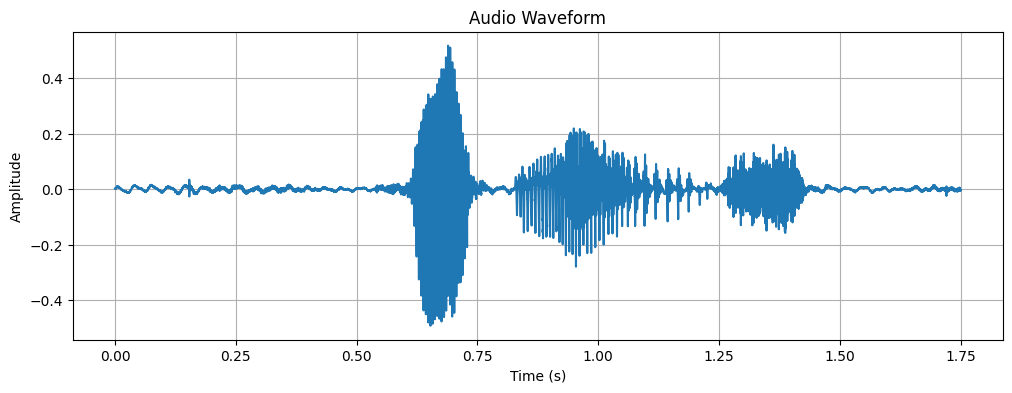

In [3]:
from IPython import display
import matplotlib.pyplot as plt
import numpy as np

def plot_audio_waveform(waveform, sample_rate):

    waveform = waveform.numpy()
    time_axis = np.arange(0, waveform.shape[1]) / sample_rate

    plt.figure(figsize=(12, 4))
    plt.plot(time_axis, waveform[0])
    plt.title("Audio Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.show()

    display.display(display.Audio(waveform, rate=sample_rate, normalize=False))

plot_audio_waveform(element["audio"], sample_rate=16000)

In [24]:
np.arange(0, element['audio'].shape[1]) / 16000

array([0.0000000e+00, 6.2500000e-05, 1.2500000e-04, ..., 2.2798125e+00,
       2.2798750e+00, 2.2799375e+00])

In [3]:
from torch.utils.data import DataLoader
from src.datasets.collate import collate_fn
from src.model.baseline_model import BaselineModel
from torch.optim import AdamW
from src.loss import CTCLossWrapper
import torch

model = BaselineModel(
    n_feats=128,
    n_tokens=len(data.text_encoder.vocab)
)

def trainer(model):
    dataloader = DataLoader(data, shuffle=False, collate_fn=collate_fn)

    for batch_idx, batch in enumerate(dataloader):
        batch['spectrogram'] = batch['spectrogram'].squeeze(0)
        outputs = model(batch["spectrogram"], batch['spectrogram'].shape[2])
        batch.update(outputs)

        batch['text_encoded'] = batch['text_encoded'].squeeze(0)
        batch['log_probs_length'] = torch.tensor(batch['log_probs_length'])
        batch['text_encoded_length'] = torch.tensor(batch['text_encoded'].shape[1])
        criterion = CTCLossWrapper()
        loss = criterion(**batch)

        batch.update(loss)
        batch['loss'].backward()
        optimizer = AdamW(model.parameters(), lr=1e-3)
        optimizer.step()
        optimizer.zero_grad() 
        print(f"Batch {batch_idx}, Loss: {batch['loss'].item()}")
        break

    out = model(element["spectrogram"], element['spectrogram'].shape[2])
    dec = data.text_encoder.decode(out['log_probs'].argmax(dim=-1).squeeze().tolist())
    print("Decoded output:", dec)

trainer(model)

torch.Size([1, 128, 116])
Batch 0, Loss: 120.550048828125
torch.Size([1, 128, 141])
Decoded output: sssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssssss


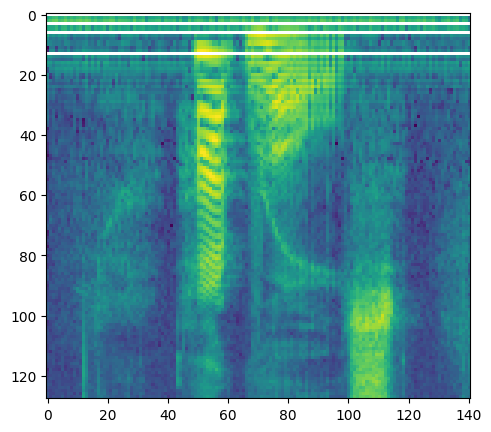

In [5]:
import torch

log_mel_spectrogram = torch.log(element['spectrogram']).squeeze()
plt.figure(figsize=(20, 5))
plt.imshow(log_mel_spectrogram)
plt.show()

In [6]:
element['spectrogram'].shape

torch.Size([1, 128, 141])

In [61]:
import math
rnn_input_size = int(math.floor((16000 * 400) / 2) + 1)
rnn_input_size = int(math.floor(rnn_input_size + 2 * 20 - 41) / 2 + 1)
rnn_input_size

1600001

In [ ]:
rnn_input_size = int(math.floor(rnn_input_size + 2 * 10 - 21) / 2 + 1)
rnn_input_size *= 32
rnn_input_size

25600032

In [12]:
seq_len = 116
padding = [20, 10]
dilation = [1, 1]
kernel_size = [41, 11]
stride = [2, 2]
out = ((seq_len + 2 * padding[1] - dilation[1] * (kernel_size[1] - 1) - 1) // stride[1] + 1)
out

63

In [3]:
from torch.utils.data import DataLoader
from src.datasets.collate import collate_fn
from src.model.deepspeech2 import DeepSpeech2
from torch.optim import AdamW
from src.loss import CTCLossWrapper
import torch

model = DeepSpeech2(
    n_feats=1,
    n_tokens=len(data.text_encoder.vocab)
)

def trainer(model):
    dataloader = DataLoader(data, shuffle=False, collate_fn=collate_fn, batch_size=4)
    criterion = CTCLossWrapper()
    optimizer = AdamW(model.parameters(), lr=1e-2)
    
    for batch_idx, batch in enumerate(dataloader):
        print(batch['spectrogram'].shape)
        outputs = model(batch["spectrogram"], batch['spectrogram'].shape[3])
        batch.update(outputs)
        optimizer.zero_grad() 

        print(f"log_probs: {batch['log_probs'].shape}")
        batch['text_encoded'] = batch['text_encoded'].squeeze(1)
        print(f"text_encoded: {batch['text_encoded'].shape}")
        print(f"log_probs_length: {batch['log_probs_length']}")

        batch_size = batch['text_encoded'].shape[0]
        text_enc_len = batch['text_encoded'].shape[1]
        batch['text_encoded_length'] = torch.full((batch_size,), text_enc_len)
        print(batch['text_encoded_length'])

        loss = criterion(**batch)
        batch.update(loss)
        batch['loss'].backward()
        optimizer.step()

        print(f"Batch {batch_idx}, Loss: {batch['loss'].item()}")
        dec = data.text_encoder.decode(outputs['log_probs'][0].argmax(dim=-1).squeeze().tolist())
        print("Decoded output:", dec)
        if batch_idx == 10:
            break

    out = model(element["spectrogram"].unsqueeze(0), torch.tensor(element['spectrogram'].shape[2]).unsqueeze(0))
    dec = data.text_encoder.decode(out['log_probs'].argmax(dim=-1).squeeze().tolist())
    print("Decoded output:", dec)

trainer(model)

d:\Python3.10\lib\site-packages\torchaudio\_backend\utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


torch.Size([4, 1, 128, 125])
torch.Size([4, 32, 32, 68])
torch.Size([4, 1024, 68])
torch.Size([4, 68, 1024])
x output torch.Size([4, 68, 28])
log_probs: torch.Size([4, 68, 28])
text_encoded: torch.Size([4, 17])
log_probs_length: tensor([68, 68, 68, 68])
tensor([17, 17, 17, 17])
Batch 0, Loss: 10.23375415802002
Decoded output: eeqqqqqqqqqvqvqqqqqqqqqqqqqqqqqqqqqqqqqq
torch.Size([4, 1, 128, 139])
torch.Size([4, 32, 32, 75])
torch.Size([4, 1024, 75])
torch.Size([4, 75, 1024])


KeyboardInterrupt: 

In [8]:
torch.tensor([1, 2, 3, 4])

tensor([1, 2, 3, 4])

In [7]:
element = data[110]

In [13]:
out = model(element["spectrogram"].unsqueeze(0), torch.tensor(element['spectrogram'].shape[2]))
dec = data.text_encoder.decode(out['log_probs'].argmax(dim=-1).squeeze().tolist())
print("Decoded output:", dec)
print(out['log_probs'].argmax(dim=-1))
print(out['log_probs'].argmax(dim=-1).shape)

torch.Size([1, 32, 32, 66])
torch.Size([1, 1024, 66])
torch.Size([1, 66, 1024])


RuntimeError: Expected `len(lengths)` to be equal to batch_size, but got 4 (batch_size=1)

In [10]:
element = data[1]
element['spectrogram'].shape

torch.Size([1, 128, 121])

In [50]:
for key in data[0].keys():
    if isinstance(data[0][key], torch.Tensor):
        padded_tensors = []
        for item in data:
            max_len = 23200
            print(item[key].shape[1])
            tensor = item[key]
            if key == "spectrogram":
                pad_size = max_len - tensor.shape[2]
            else:
                pad_size = max_len - tensor.shape[1]
            print(f"Pad size {pad_size}")
            padded_tensor = torch.nn.functional.pad(tensor, (0, pad_size), "constant", 0)
            padded_tensors.append(padded_tensor)
            break
        print(padded_tensors[0].shape)

23120
Pad size 80
torch.Size([1, 23200])
128
Pad size 23084
torch.Size([1, 128, 23200])
3
Pad size 23197
torch.Size([1, 23200])


d:\Python3.10\lib\site-packages\torchaudio\_backend\utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


In [19]:
dataloader = DataLoader(data, shuffle=False, collate_fn=collate_fn, batch_size=2)
for batch in dataloader:
    print(batch)
    break

{'audio': tensor([[[-2.4414e-03, -2.7161e-03, -3.1128e-03,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00]],

        [[-9.1553e-05, -3.6621e-04, -4.8828e-04,  ...,  2.1362e-04,
           2.4414e-04,  3.3569e-04]]]), 'spectrogram': tensor([[[[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [8.4964e-02, 3.2635e-02, 4.1000e-02,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [4.5747e-01, 1.7572e-01, 2.2075e-01,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          ...,
          [2.1332e-05, 2.4385e-05, 7.7396e-06,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [2.6075e-06, 1.6093e-05, 1.2169e-05,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [1.2396e-05, 1.7917e-05, 1.8519e-05,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00]]],


        [[[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [1.5140e-03, 1.8313e-03,